# Scaling 기반 고객 군집화

수치형 변수는 원본 값을 유지하되 scaling하고, 범주형 변수는 One-Hot Encoding한 뒤 KMeans 군집화를 진행한다. `churned`는 군집 생성에는 사용하지 않고, 군집 생성 이후 군집별 이탈률 해석에만 사용한다.

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='Set2', font=font_name)

RANDOM_STATE = 42
print(f'사용 폰트: {font_name}')

사용 폰트: AppleGothic


In [2]:
data_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
]
data_path = next(path for path in data_candidates if path.exists())

raw_df = pd.read_csv(data_path)
raw_df.shape, raw_df.head()

((50000, 20),
   user_id  age  gender         region subscription_type payment_method  \
 0  N00001   33    Male         Europe             Basic    Credit Card   
 1  N00002   41    Male         Africa           Premium    Credit Card   
 2  N00003   28  Female         Europe          Standard      Gift Card   
 3  N00004   40  Female  North America             Basic    Credit Card   
 4  N00005   54    Male         Europe          Standard         Paypal   
 
   primary_device  account_age_months favorite_genre time_of_day  \
 0       Smart TV                  38         Comedy   Afternoon   
 1         Tablet                  49         Comedy     Evening   
 2         Laptop                  20          Drama     Evening   
 3         Mobile                  19         Action     Evening   
 4         Mobile                  51        Romance     Evening   
 
   recommendation_source  session_count  avg_watch_time_minutes_per_week  \
 0              Trending              1         

## 군집화 피처 설계

- 제외: `user_id`, `churned`, `region`, `gender`
- 수치형: 원본 값을 유지하고 `StandardScaler` 적용
- 범주형: `OneHotEncoder` 적용
- 해석: 군집 생성 후 `churned`를 붙여 군집별 이탈률과 프로파일을 확인

In [3]:
cluster_feature_cols = [
    'age',
    'account_age_months',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
    'session_count',
    'avg_watch_time_minutes_per_week',
    'watch_sessions_per_week',
    'completion_rate',
    'avg_rating_given',
    'app_rating',
    'recommendation_click_rate',
    'days_since_last_login',
]

cluster_df = raw_df[cluster_feature_cols].copy()

numeric_features = cluster_df.select_dtypes(include='number').columns.tolist()
categorical_features = cluster_df.select_dtypes(include=['object', 'string']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
cluster_df.head()

Numeric features: ['age', 'account_age_months', 'session_count', 'avg_watch_time_minutes_per_week', 'watch_sessions_per_week', 'completion_rate', 'avg_rating_given', 'app_rating', 'recommendation_click_rate', 'days_since_last_login']
Categorical features: ['subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'time_of_day', 'recommendation_source']


,age,account_age_months,subscription_type,payment_method,primary_device,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login
0,33,38,Basic,Credit Card,Smart TV,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3
1,41,49,Premium,Credit Card,Tablet,Comedy,Evening,Search,1,164,4,69,4,4,32,30
2,28,20,Standard,Gift Card,Laptop,Drama,Evening,Ads,1,304,5,75,4,3,31,5
3,40,19,Basic,Credit Card,Mobile,Action,Evening,Algorithm,1,145,6,79,4,4,39,38
4,54,51,Standard,Paypal,Mobile,Romance,Evening,Friend,3,108,1,58,5,4,50,5


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    sparse_threshold=0.0,
)

X_cluster = preprocessor.fit_transform(cluster_df)
X_cluster.shape

(50000, 37)

## 군집 수 선택

`k=2~8` 범위를 확인한다. Silhouette score는 계산 비용을 줄이기 위해 표본 10,000개 기준으로 계산한다.

In [5]:
k_rows = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(
        X_cluster,
        labels,
        sample_size=min(10000, X_cluster.shape[0]),
        random_state=RANDOM_STATE,
    )
    k_rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': score})

k_result = pd.DataFrame(k_rows)
k_result

,k,inertia,silhouette
0,2,619398.028737,0.126925
1,3,581128.593098,0.086027
2,4,558324.652904,0.083471
3,5,537720.603684,0.068512
4,6,520582.388375,0.068372
5,7,510353.114528,0.061355
6,8,501379.652795,0.058569


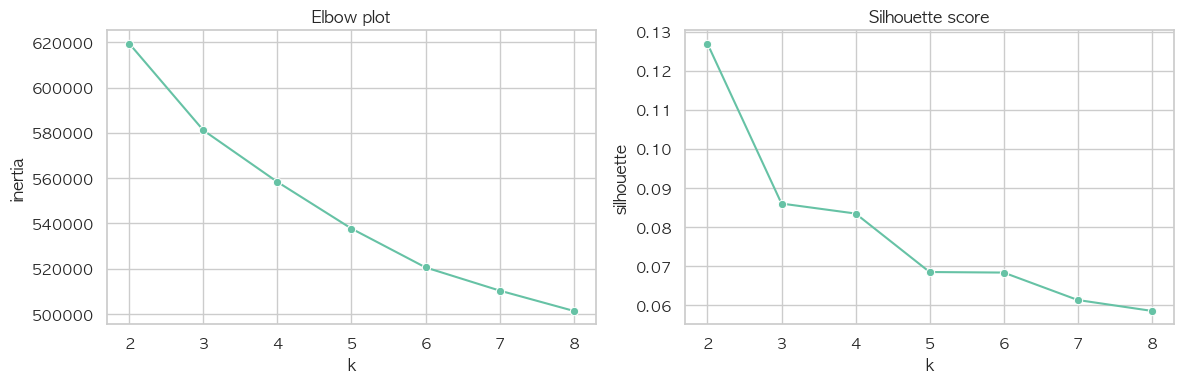

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_result, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow plot')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')

sns.lineplot(data=k_result, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')

plt.tight_layout()
plt.show()

**실제 해석**

- Silhouette score는 `k=2`에서 약 0.1269로 가장 높다. 다만 `k=2`는 고객군을 고위험/저위험 정도로만 나누어 비즈니스 해석이 단순해질 수 있다.
- `k=3`의 silhouette score는 약 0.0860으로 `k=2`보다 낮지만, 이탈 위험군, 일반 유지군, 핵심 충성군으로 나뉘어 해석 가능성이 더 좋다.
- `k=4` 이후에는 silhouette score가 더 낮아지고 군집이 잘게 쪼개지는 경향이 있다.
- 따라서 이 노트북에서는 해석 가능성과 실무 활용성을 기준으로 기본 `SELECTED_K = 3`을 사용한다.

## 최종 군집 생성

`SELECTED_K`는 기본 3으로 둔다. 그래프 결과에 따라 필요하면 수정한다.

In [7]:
SELECTED_K = 3

kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

analysis_df = raw_df.copy()
analysis_df['cluster'] = cluster_labels

analysis_df['cluster'].value_counts().sort_index()

cluster
0    10360
1    14335
2    25305
Name: count, dtype: int64

## PCA 시각화

전처리된 고차원 데이터를 2차원 PCA로 투영해 군집 분포와 이탈 고객 분포를 확인한다. PCA는 시각화용이다.

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    'pca_1': pca_coords[:, 0],
    'pca_2': pca_coords[:, 1],
    'cluster': analysis_df['cluster'].astype(str),
    'churned': analysis_df['churned'].map({0: '유지', 1: '이탈'}),
})

pd.DataFrame({
    'component': ['pca_1', 'pca_2'],
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'cumulative_explained_variance_ratio': pca.explained_variance_ratio_.cumsum(),
})

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,pca_1,0.214895,0.214895
1,pca_2,0.076137,0.291031


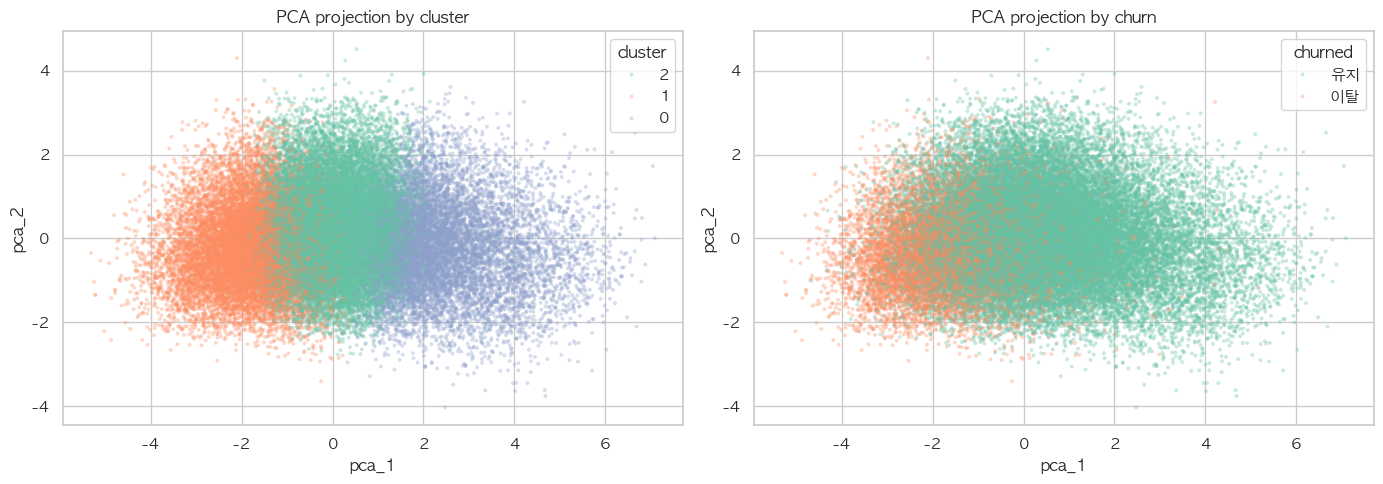

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    s=8,
    alpha=0.35,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('PCA projection by cluster')

sns.scatterplot(
    data=pca_df,
    x='pca_1',
    y='pca_2',
    hue='churned',
    s=8,
    alpha=0.35,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('PCA projection by churn')

plt.tight_layout()
plt.show()

**실제 해석**

- PCA 2차원 누적 설명분산은 약 29.1%이다. 고차원 전처리 데이터를 2차원으로 압축한 결과이므로 scatter plot만으로 군집 품질을 단정하기는 어렵다.
- 그래도 PCA plot은 cluster가 대략 어떤 방향으로 분리되는지, 이탈 고객이 특정 군집/영역에 몰리는지 확인하는 데 유용하다.
- 최종 판단은 PCA 그림보다 `cluster_summary`의 이탈률, lift, 고객 수, 주요 범주형 분포를 중심으로 하는 것이 적절하다.

## 군집별 이탈률과 프로파일

In [10]:
overall_churn_rate = analysis_df['churned'].mean()

cluster_summary = (
    analysis_df.groupby('cluster')
    .agg(
        users=('user_id', 'count'),
        churners=('churned', 'sum'),
        churn_rate=('churned', 'mean'),
        avg_age=('age', 'mean'),
        avg_account_age_months=('account_age_months', 'mean'),
        avg_days_since_last_login=('days_since_last_login', 'mean'),
        avg_watch_time=('avg_watch_time_minutes_per_week', 'mean'),
        avg_watch_sessions=('watch_sessions_per_week', 'mean'),
        avg_completion_rate=('completion_rate', 'mean'),
        avg_recommendation_click_rate=('recommendation_click_rate', 'mean'),
    )
    .assign(
        user_share=lambda x: x['users'] / len(analysis_df),
        churner_share=lambda x: x['churners'] / analysis_df['churned'].sum(),
        lift=lambda x: x['churn_rate'] / overall_churn_rate,
    )
    .sort_values('churn_rate', ascending=False)
)

cluster_summary

,users,churners,churn_rate,avg_age,avg_account_age_months,avg_days_since_last_login,avg_watch_time,avg_watch_sessions,avg_completion_rate,avg_recommendation_click_rate,user_share,churner_share,lift
cluster,,,,,,,,,,,,,
1,14335,7830,0.546216,38.674712,38.081130,27.716638,175.725706,3.719916,64.745309,26.651692,0.2867,0.74828,2.609975
2,25305,2395,0.094645,39.376526,45.919660,5.796839,242.008417,4.893578,73.842758,41.165422,0.5061,0.22888,0.452243
0,10360,239,0.023069,39.572394,51.378089,6.859266,507.189286,10.561390,82.977606,49.062838,0.2072,0.02284,0.110233


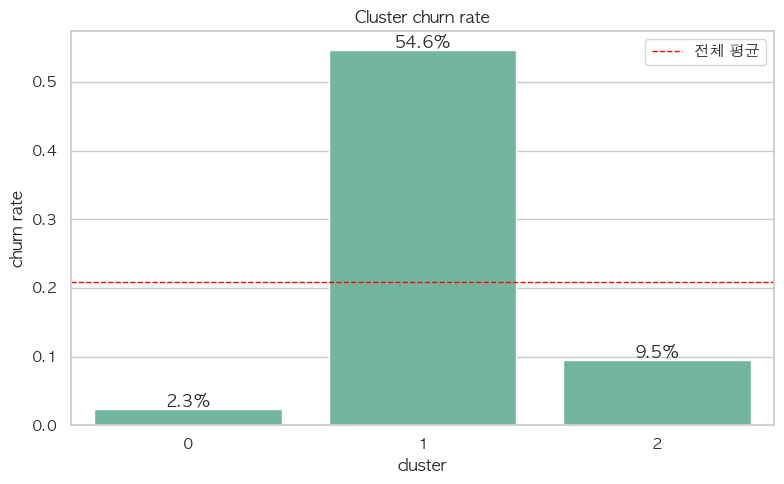

In [11]:
plot_summary = cluster_summary.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_summary, x='cluster', y='churn_rate', ax=ax)
ax.axhline(overall_churn_rate, color='red', linestyle='--', linewidth=1, label='전체 평균')
ax.set_title('Cluster churn rate')
ax.set_xlabel('cluster')
ax.set_ylabel('churn rate')
ax.legend()

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v.get_height():.1%}' for v in container])

plt.tight_layout()
plt.show()

**실제 해석**

- Cluster 1은 이탈률이 약 54.6%로 가장 높고, 전체 평균 대비 lift가 약 2.61이다. 전체 고객의 28.7%이지만 전체 이탈자의 74.8%를 차지하므로 최우선 관리 대상이다.
- Cluster 2는 이탈률이 약 9.5%로 전체 평균보다 낮고, 고객 수가 가장 큰 일반 유지 고객군이다.
- Cluster 0은 이탈률이 약 2.3%로 가장 낮고, 전체 이탈자의 2.3%만 차지한다. 핵심 충성 고객군으로 볼 수 있다.
- scaling 기반 군집화는 이탈 위험도를 기준으로 고위험군, 일반군, 충성군이 비교적 명확하게 나뉜다.

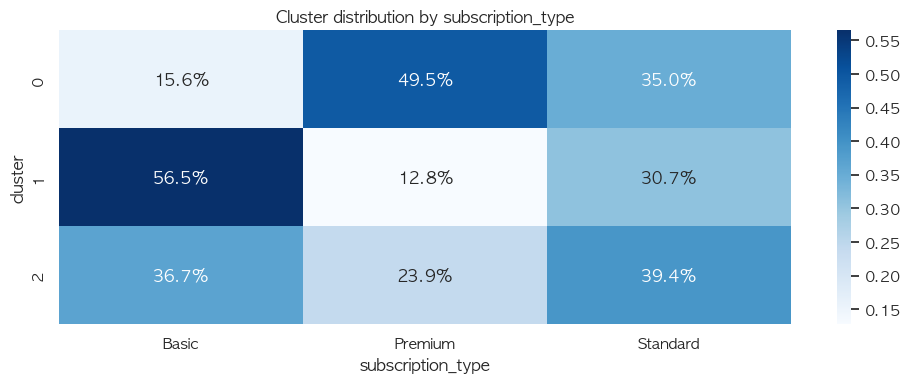

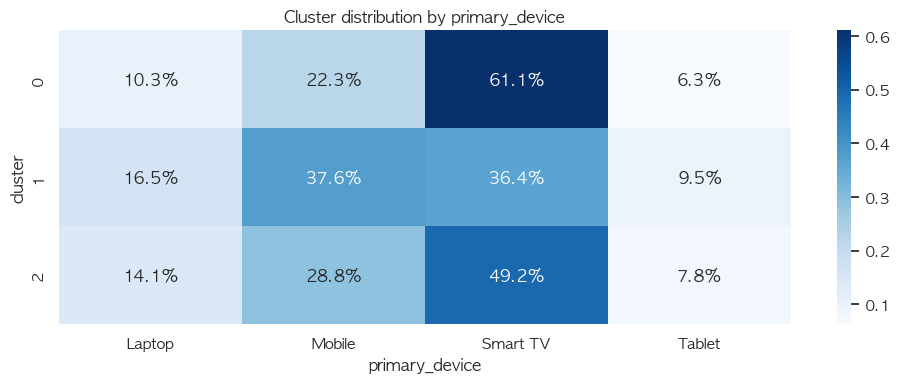

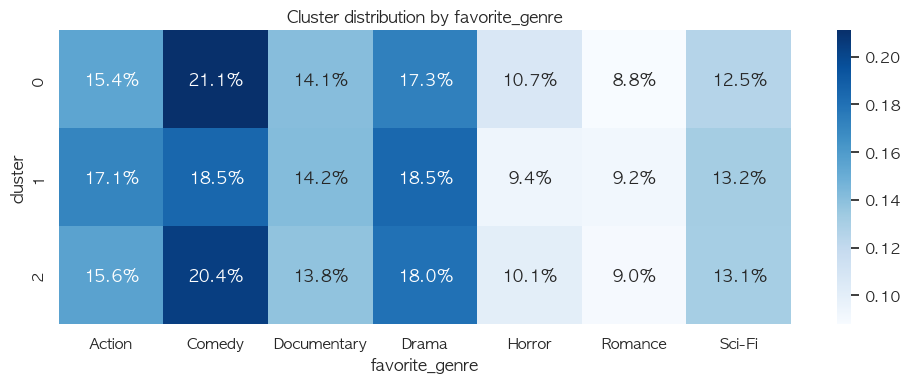

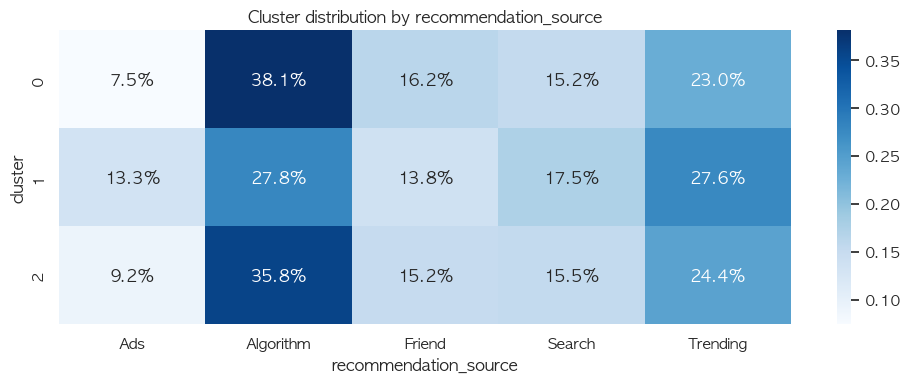

In [12]:
for col in ['subscription_type', 'primary_device', 'favorite_genre', 'recommendation_source']:
    dist = pd.crosstab(analysis_df['cluster'], analysis_df[col], normalize='index')
    plt.figure(figsize=(10, 4))
    sns.heatmap(dist, annot=True, fmt='.1%', cmap='Blues')
    plt.title(f'Cluster distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('cluster')
    plt.tight_layout()
    plt.show()

**실제 해석**

- Cluster 1은 `Basic` 비중이 높고 `Mobile` 사용 비중이 상대적으로 높다. 평균 로그인 공백도 약 27.7일로 길어, 저활동 Basic/Mobile 고객 중심의 고위험군으로 해석된다.
- Cluster 2는 `Standard` 비중이 상대적으로 높고, 시청 시간과 추천 클릭률이 중간 수준이다. 대규모 일반 유지 고객군에 가깝다.
- Cluster 0은 `Premium`과 `Smart TV` 비중이 높고, 평균 주당 시청 시간이 약 507분, 시청 세션이 약 10.6회로 가장 높다. 충성도 높은 고가치 고객군으로 해석된다.
- 장르는 모든 군집에서 `Comedy`가 가장 큰 비중을 차지해, 장르만으로 군집을 강하게 구분하기는 어렵다.
- 추천 경로는 Cluster 0과 2에서 `Algorithm` 비중이 높고, Cluster 1은 상대적으로 다양한 유입 경로가 섞여 있다.

## 전체 결론

- scaling 기반 `k=3` KMeans는 고객을 `고위험 이탈군`, `일반 유지군`, `핵심 충성군`으로 나누는 데 적합하다.
- Cluster 1은 고객 수와 이탈자 수가 모두 크므로 리텐션 캠페인, 복귀 혜택, Basic Plus/Mobile Plus 같은 방어형 요금제 실험의 최우선 대상이다.
- Cluster 2는 대규모 일반 유지 고객군이므로 과도한 할인보다 추천 품질 유지와 사용 경험 개선 중심의 관리가 적합하다.
- Cluster 0은 이탈률이 매우 낮은 충성 고객군이므로 할인보다 프리미엄 경험 강화, VIP 혜택, 장기 구독 유지 전략이 적합하다.
- 범주화 기반 노트북과 비교할 때는 `users`, `churn_rate`, `lift`, 대표 요금제/기기/장르/추천 경로를 같은 포맷으로 비교한다.